In [32]:
# let's load in all our data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

adc_blank = 1.89
od_init = 0.11
dil_fact = 10000
vol_on_plt = 0.1 # mL
cell_cult_vol = 3 # mL

filename = "data/experiment_3.csv"
data = pd.read_csv(filename, header=None, usecols=[0, 1])
data.columns = ["adc", "time"]

print(data.head())
print(data.columns)

def adc_to_od(voltage, v_0):
    return -1 * np.log10(voltage/v_0)


data["od_val"] = adc_to_od(data["adc"], adc_blank)

print(data.head())

     adc   time
0  1.894      0
1  1.888   6018
2  1.896  12020
3  1.903  18023
4  1.886  24025
Index(['adc', 'time'], dtype='object')
     adc   time    od_val
0  1.894      0 -0.000918
1  1.888   6018  0.000460
2  1.896  12020 -0.001377
3  1.903  18023 -0.002977
4  1.886  24025  0.000920


In [ ]:
# let's prepare our data and convert to numpy

x = data["time"].to_numpy()
y = data["od_val"].to_numpy()

mask = (y > 0)
x_lin = x[mask]
y_lin = np.log(y[mask])

count = 0
for elem in y:
    if elem > 0:
        count += 1

13886
14251


In [29]:
# function that determines region with exponential growth

def is_linear(start, stop, xs, ys, r2_floor=0.99):
    mask = (xs >= start) & (xs <= stop)
    xs = xs[mask]
    ys = ys[mask]

    m, b = np.polyfit(xs, ys, 1)

    # calculate r^2
    r2 = r2_score(ys, m * xs + b)

    return r2 > r2_floor, xs, ys, m, b, r2

In [30]:
# let's find the best region for linearity...

def region_score(x_start, x_stop, xs, ys):
    # mask xs and ys
    mask = (xs >= x_start) & (xs <= x_stop)
    xs = xs[mask]
    ys = ys[mask]

    # find best fit line for data in this range
    m, b = np.polyfit(xs, ys, 1)
    ys_pred = m * xs + b

    # calculate r^2 value
    r2 = r2_score(ys, ys_pred)

    # use our scoring formula -> region_score = r^2 - (1/reg_length)
    return r2 - (1.0/(len(xs)*100)), m, b, r2

min_range = 3
high_score = 0
best_start = best_stop = m_best = b_best = r2_best = None

# for start in range(0, len(x) - min_range):
#     for stop in range(start + min_range-1, len(x)):
#         reg_score, m, b, r2 = region_score(x[start], x[stop], x, y)
#         if reg_score > high_score:
#             high_score = reg_score
#             best_start = start
#             best_stop = stop
#             m_best = m
#             b_best = b
#             r2_best = r2

for start in range(0, len(x_lin) - min_range):
    for stop in range(start + min_range-1, len(x_lin)):
        linear, _, _, mb, bb, r2 = is_linear(x_lin[start], x_lin[stop], x_lin, y_lin)
        if linear and (stop - start > high_score):
            high_score = stop - start
            best_start = start
            best_stop = stop
            m_best = mb
            b_best = bb
            r2_best = r2

print(f"Best region for linearity:\nr2 = {r2_best}\nbest_start = {best_start}\nbest_stop = {best_stop}")


KeyboardInterrupt: 

In [10]:
# let's print our best fit line based on calculated range

x_fit = np.linspace(x_lin[best_start], x_lin[best_stop], 100)
y_fit = m_best * x_fit + b_best

mask_best = (x_lin >= x_lin[best_start]) & (x_lin <= x_lin[best_stop])
x_reg = x_lin[mask_best]
y_reg = y_lin[mask_best]

TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

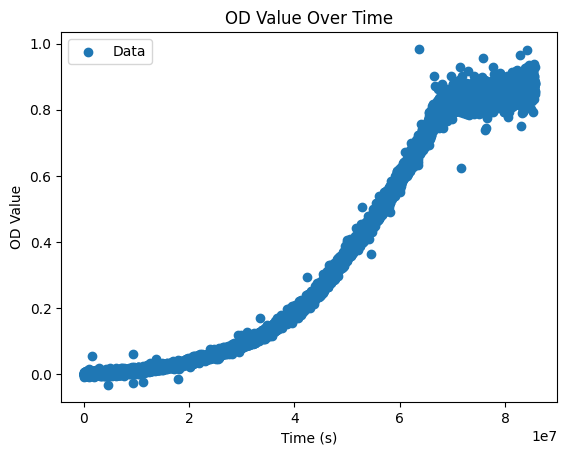

In [39]:
# plot shit

plt.figure()
plt.scatter(x, y, label="Data")
# plt.plot(
#     x_fit, y_fit,
#     label=f"y = {m_best:.2e}x - {abs(b_best):.3f}\n$R^2$ = {r2_best:.10f}",
#     color="red"
# )
# plt.scatter(
#     [x_reg[0], x_reg[-1]],
#     [y_reg[0], y_reg[-1]],
#     color="red",
#     zorder=5,
#     label="Fit region endpoints"
# )
plt.xlabel("Time (s)")
plt.ylabel("OD Value")
plt.title("OD Value Over Time")
plt.legend()
plt.show()

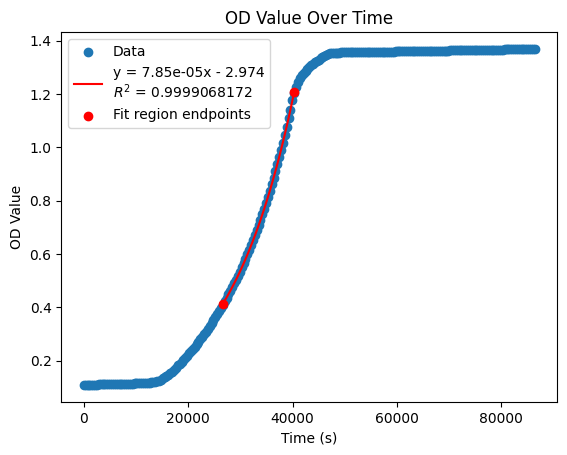

In [ ]:
# let's go back to exponential

# x and y already defined

# y = B * e ** (A * x)
# ln(y) = Ax + lnB
# b = lnB -> B = exp(b)
# m = A

# A = m_best
# B = np.exp(b_best)
# x_exp = x[mask]
# y_exp = B * np.exp(A * x_exp)

y_fit = np.exp(y_fit)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(
    x_fit, y_fit,
    label=f"y = {m_best:.2e}x - {abs(b_best):.3f}\n$R^2$ = {r2_best:.10f}",
    color="red"
)
plt.scatter(
    [x_fit[0], x_fit[-1]],
    [y_fit[0], y_fit[-1]],
    color="red",
    zorder=5,
    label="Fit region endpoints"
)
plt.xlabel("Time (s)")
plt.ylabel("OD Value")
plt.title("OD Value Over Time")
plt.legend()
plt.show()

